# Introdução



Este exercício didático tem dois propósitos:

- Conhecer mais sobre o modelo [Before.IT](https://github.com/bancaditalia/BeforeIT.jl) e suas nuances de implementação.
- Explicar os impactos causados pela modificação que transfere parte da renda da população trabalhadora para os donos das empresas (proxy da criação de um mercado de apostas).

## Agentes e suas condições iniciais

O estado da economia é dividido em dois componentes, os parâmetros e as condições iniciais:

- **Condições iniciais** representam o estado da economia no começo da simulação, como renda dos agentes, depósitos, capital, dívida pública, patrimônio do banco e taxa de juros inicial. Estes valores mudam ao longo do tempo.

- **Parâmetros** representam as regras e os comportamentos do modelo, como taxas de impostos, propensão ao consumo, juros e quantidade de agentes. Permanecem fixos durante a simulação.

Nesta primeira parte, vamos entender as condições iniciais dos participantes da economia, são eles:  

- Trabalhadores.
- Empresas e donos das empresas.
- Bancos e dono do banco.
- Banco central. 
- Governo.
- Resto do Mundo.

Por fim, vamos calcular o índice de Gini dos agentes pessoas físicas e verificar o estado atual dos agregados macroeconômicos. 

In [ ]:
import BeforeIT as Bit # importando o modelo
using DataFrames
using Plots
using StatsBase
using Random

Random.seed!(123)

model = Bit.Model(
    Bit.AUSTRIA2010Q1.parameters,  # parametros das regras necessárias para rodar o modelo
    Bit.AUSTRIA2010Q1.initial_conditions, # condições iniciais analisadas abaixo
);

## Trabalhadores

Cada trabalhador possui um conjunto único de variáveis, que são uma das fontes de heterogeneidade do modelo. São elas: 

- `category`: categoria do trabalhador, indicando se ele é ativo (`"active"`) ou inativo (`"inactive"`, ex: aposentados).

- `id`: identificador único do trabalhador dentro do seu grupo.

- `income`: renda líquida disponível do trabalhador (`Y_h`). 

- `deposits`: depósitos ou poupança financeira acumulada pelo trabalhador (`D_h`).

- `capital`: estoque de capital do trabalhador (`K_h`).

- `wage`: salário do trabalhador (`w_h`). Para trabalhadores inativos, é zero. O salário é determinado pela ocupação, que é determinado pela empresa que o trabalhador é vinculado. 

- `occupation`: situação ocupacional ou vínculo com uma empresa (`O_h`):

  - Valor maior que `0`: trabalhador empregado. O valor representa o ID da empresa.
  - Valor igual a `0`: trabalhador ativo, mas desempregado.
  - Valor igual a `-1`: trabalhador inativo.

- `consumption_budget`: orçamento que o trabalhador deseja gastar em consumo (`C_d_h`).

- `investment_budget`: orçamento que o trabalhador deseja gastar em investimento (`I_d_h`).

- `realised_consumption`: consumo que efetivamente aconteceu depois das interações no mercado (`C_h`).

- `realised_investment`: investimento que efetivamente aconteceu depois das interações no mercado (`I_h`).

In [163]:
function worker_table(workers, category)
    DataFrame(
        category = fill(category, length(workers)),
        id = workers.ID,
        income = workers.Y_h,
        deposits = workers.D_h,
        capital = workers.K_h,
        wage = workers.w_h,
        occupation = workers.O_h,
        consumption_budget = workers.C_d_h,
        investment_budget = workers.I_d_h,
        realised_consumption = workers.C_h,
        realised_investment = workers.I_h,
    )
end

active_workers = worker_table(model.w_act, "active")
inactive_workers = worker_table(model.w_inact, "inactive")

all_workers = vcat(active_workers, inactive_workers);

In [164]:
occupation_status = ifelse.(
    all_workers.occupation .== -1,
    "Inactive",
    ifelse.(
        all_workers.occupation .== 0,
        "Unemployed",
        "Employed",
    ),
)

status_counts = combine(
    groupby(DataFrame(status = occupation_status), :status),
    nrow => :workers,
)

p1 = histogram(
    all_workers.income;
    bins = 30,
    title = "Income distribution",
    xlabel = "Income",
    ylabel = "Workers",
    legend = false,
);

p3 = histogram(
    all_workers.deposits;
    bins = 30,
    title = "Deposit distribution",
    xlabel = "Deposits",
    ylabel = "Workers",
    legend = false,
)

p4 = histogram(
    all_workers.capital;
    bins = 30,
    title = "Capital distribution",
    xlabel = "Capital",
    ylabel = "Workers",
    legend = false,
)

p5 = bar(
    status_counts.status,
    status_counts.workers;
    title = "Occupation status",
    xlabel = "Status",
    ylabel = "Workers",
    legend = false,
);


Distribuição da renda, dos depósitos, do capital e da ocupação dos trabalhadores:

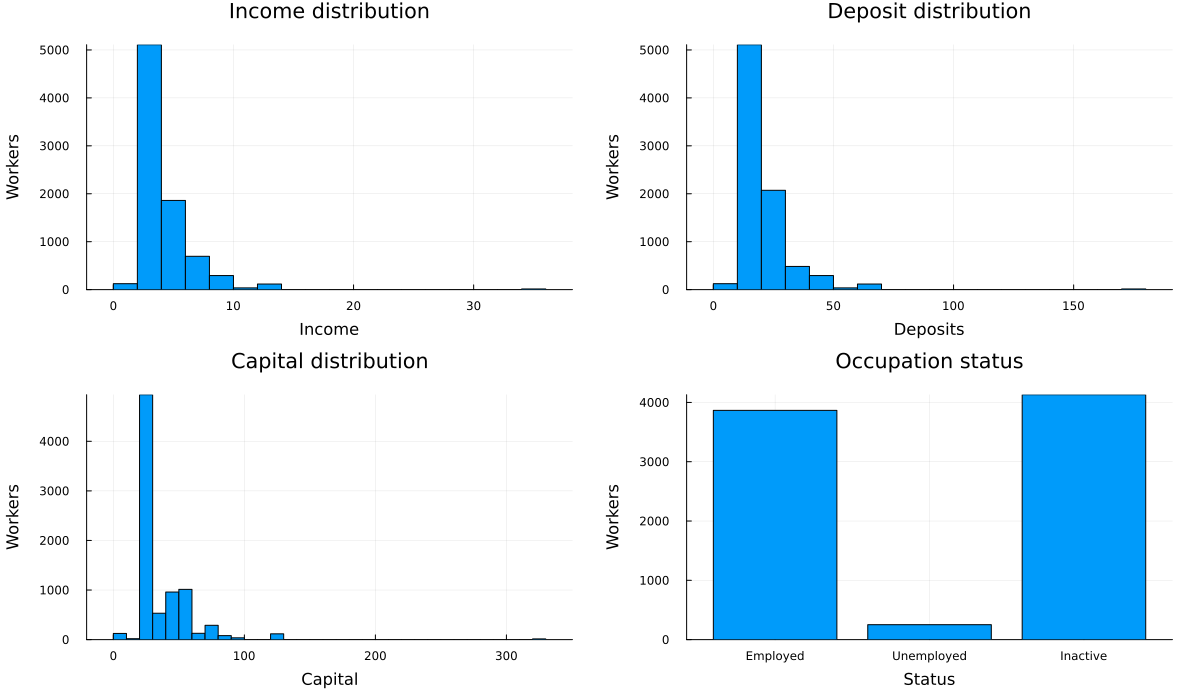

In [165]:
plot(
    p1,
    p3,
    p4,
    p5;
    layout = (2, 2),
    size = (1200, 700),
    margin = 5Plots.mm,
)

Visão estatística das condições iniciais dos trabalhadores:

In [166]:
describe(select(
    all_workers,
    :income,
    :deposits,
    :capital,
    :wage,
    :consumption_budget,
    :investment_budget,
    :realised_consumption,
    :realised_investment))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,income,4.07514,0.766128,2.82875,35.6449,0,Float64
2,deposits,20.116,3.78181,13.9635,175.953,0,Float64
3,capital,37.0929,6.97348,25.748,324.449,0,Float64
4,wage,3.78181,0.0,0.0,53.7674,0,Float64
5,consumption_budget,0.0,0.0,0.0,0.0,0,Float64
6,investment_budget,0.0,0.0,0.0,0.0,0,Float64
7,realised_consumption,0.0,0.0,0.0,0.0,0,Float64
8,realised_investment,0.0,0.0,0.0,0.0,0,Float64


## Donos das empresas

Agora vamos explorar as mesmas variáveis mas para os donos das empresas. Os dados dos donos das empresas ficam nos objetos das empresa. São elas: 

- `owner_id` (`model.firms.ID`): identificador do proprietário e da empresa correspondente.

- `sector` (`model.firms.G_i`): setor econômico no qual a empresa do proprietário atua.

- `income` (`model.firms.Y_h`): renda disponível recebida pelo proprietário.

- `deposits` (`model.firms.D_h`): depósitos financeiros pessoais do proprietário.

- `capital` (`model.firms.K_h`): estoque de capital do proprietário.

- `consumption_budget` (`model.firms.C_d_h`): orçamento que o proprietário deseja gastar em consumo pessoal.

- `investment_budget` (`model.firms.I_d_h`): orçamento que o proprietário deseja gastar em investimento habitacional.

- `realised_consumption` (`model.firms.C_h`): consumo pessoal que efetivamente aconteceu após as interações no mercado.

- `realised_investment` (`model.firms.I_h`): investimento habitacional que efetivamente aconteceu após as interações no mercado.

- `firm_profit` (`model.firms.Pi_i`): lucro gerado pela empresa associada ao proprietário.

- `firm_employment` (`model.firms.N_i`): número de trabalhadores empregados pela empresa.

- `firm_deposits` (`model.firms.D_i`): depósitos pertencentes à empresa, e não ao proprietário.

- `firm_loans` (`model.firms.L_i`): saldo dos empréstimos ou dívidas da empresa.

- `firm_equity` (`model.firms.E_i`): patrimônio líquido da empresa, calculado a partir dos seus ativos e passivos.

- `firm_production` (`model.firms.Y_i`): quantidade de bens ou serviços produzidos pela empresa.

In [167]:
firms = model.firms

firm_owners = DataFrame(
    owner_id = firms.ID,
    sector = firms.G_i,

    # Owner household data
    income = firms.Y_h,
    deposits = firms.D_h,
    capital = firms.K_h,
    consumption_budget = firms.C_d_h,
    investment_budget = firms.I_d_h,
    realised_consumption = firms.C_h,
    realised_investment = firms.I_h,

    # Associated firm data
    firm_profit = firms.Pi_i,
    firm_employment = firms.N_i,
    firm_deposits = firms.D_i,
    firm_loans = firms.L_i,
    firm_equity = firms.E_i,
    firm_production = firms.Y_i,
);


Estatísticas dos donos das empresas:

In [168]:
describe(select(
    firm_owners,
    :income,
    :deposits,
    :capital,
    :consumption_budget,
    :investment_budget,
    :realised_consumption,
    :realised_investment,
    :firm_profit,
    :firm_employment,
    :firm_deposits,
    :firm_loans,
    :firm_equity,
    :firm_production,
))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,income,11.5846,0.590286,3.06643,473.535,0,Float64
2,deposits,57.1848,2.9138,15.1367,2337.49,0,Float64
3,capital,105.446,5.37292,27.9114,4310.22,0,Float64
4,consumption_budget,0.0,0.0,0.0,0.0,0,Float64
5,investment_budget,0.0,0.0,0.0,0.0,0,Float64
6,realised_consumption,0.0,0.0,0.0,0.0,0,Float64
7,realised_investment,0.0,0.0,0.0,0.0,0,Float64
8,firm_profit,16.3063,-194.639,4.34025,828.987,0,Float64
9,firm_employment,6.19551,1,2.0,191,0,Int64


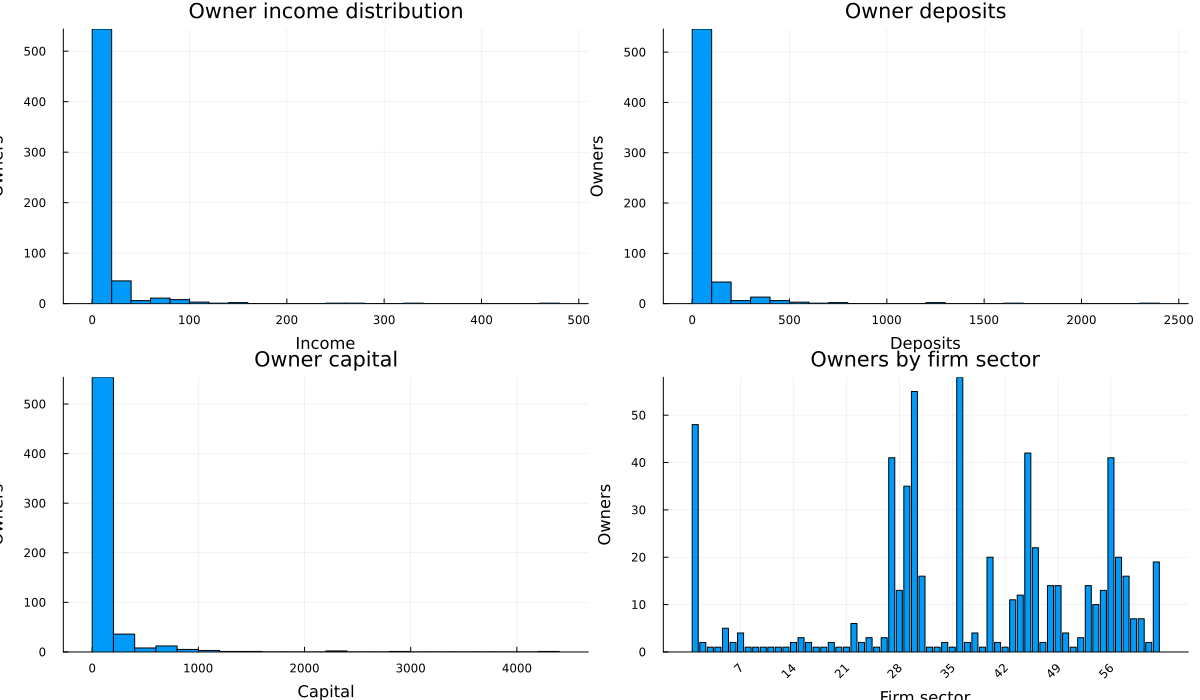

In [169]:

sector_counts = combine(
    groupby(firm_owners, :sector),
    nrow => :number_of_owners,
)

p1 = histogram(
    firm_owners.income;
    bins = 30,
    title = "Owner income distribution",
    xlabel = "Income",
    ylabel = "Owners",
    label = false,
)

p3 = histogram(
    firm_owners.deposits;
    bins = 30,
    title = "Owner deposits",
    xlabel = "Deposits",
    ylabel = "Owners",
    label = false,
)

p4 = histogram(
    firm_owners.capital;
    bins = 30,
    title = "Owner capital",
    xlabel = "Capital",
    ylabel = "Owners",
    label = false,
)

p5 = bar(
    string.(sector_counts.sector),
    sector_counts.number_of_owners;
    title = "Owners by firm sector",
    xlabel = "Firm sector",
    ylabel = "Owners",
    xrotation = 45,
    label = false,
)

plot(
    p1,
    p3,
    p4,
    p5;
    layout = (2, 2),
    size = (1200, 700),
)

## Banco comercial

Suas variáveis de estado são:

- `bank_equity` (`model.bank.E_k`): patrimônio líquido ou capital próprio do banco, usado para absorver perdas e sustentar suas operações.

- `bank_profit` (`model.bank.Pi_k`): lucro realizado pelo banco no período atual.

- `expected_bank_profit` (`model.bank.Pi_e_k`): lucro que o banco espera obter no próximo período.

- `bank_balance_item` (`model.bank.D_k`): item residual que equilibra o balanço patrimonial do banco, considerando depósitos, empréstimos e capital próprio.

- `loan_interest_rate` (`model.bank.r`): taxa de juros cobrada pelo banco sobre empréstimos e financiamentos habitacionais.

## Proprietário do banco

Suas variáveis de estado são:

- `income` (`model.bank.Y_h`): renda disponível recebida pelo proprietário do banco, principalmente por meio da distribuição dos lucros bancários.

- `deposits` (`model.bank.D_h`): depósitos financeiros pessoais do proprietário do banco.

- `capital` (`model.bank.K_h`): estoque de capital do proprietário.

- `consumption_budget` (`model.bank.C_d_h`): orçamento que o proprietário deseja gastar em consumo pessoal.

- `investment_budget` (`model.bank.I_d_h`): orçamento que o proprietário deseja gastar em investimento habitacional.

- `realised_consumption` (`model.bank.C_h`): consumo pessoal que efetivamente aconteceu após as interações no mercado.

- `realised_investment` (`model.bank.I_h`): investimento habitacional que efetivamente aconteceu após as interações no mercado.

Row,owner_id,income,deposits,capital,consumption_budget,investment_budget,realised_consumption,realised_investment,bank_profit,expected_bank_profit,bank_equity,bank_balance_item,loan_interest_rate
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,3695.37,18241.3,33636.1,0.0,0.0,0.0,0.0,6476.29,0.0,89460.0,126431.0,0.0283599


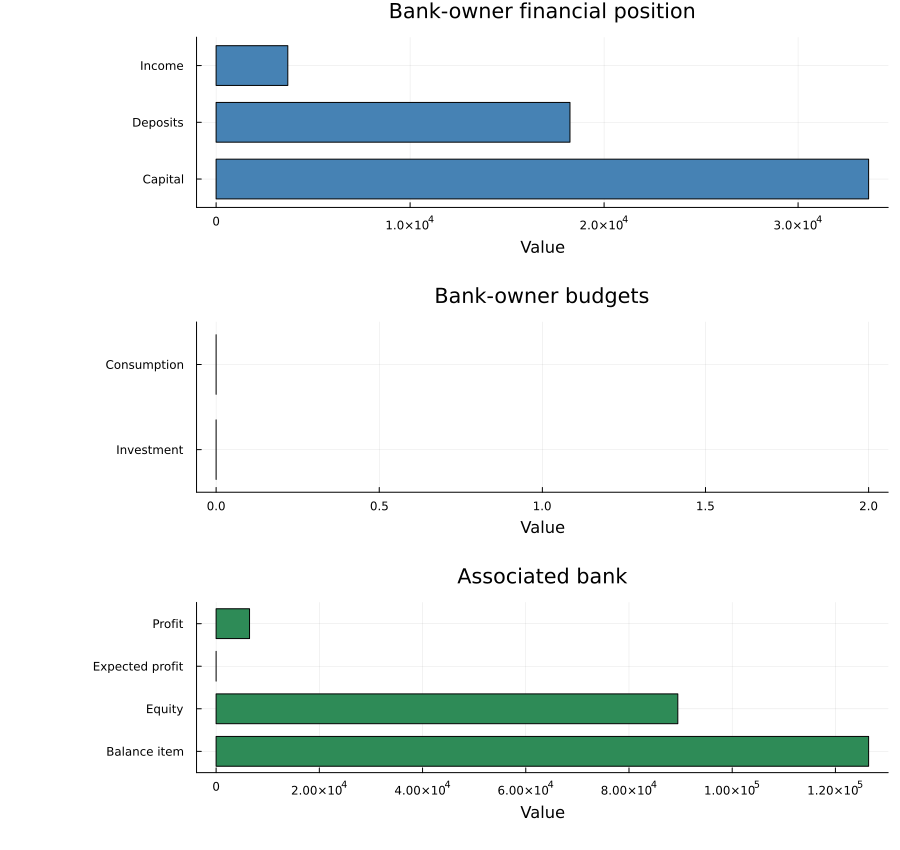

In [170]:
bank = model.bank

bank_owner = DataFrame([
    (
        owner_id = 1,
        income = bank.Y_h,
        deposits = bank.D_h,
        capital = bank.K_h,
        consumption_budget = bank.C_d_h,
        investment_budget = bank.I_d_h,
        realised_consumption = bank.C_h,
        realised_investment = bank.I_h,
        bank_profit = bank.Pi_k,
        expected_bank_profit = bank.Pi_e_k,
        bank_equity = bank.E_k,
        bank_balance_item = bank.D_k,
        loan_interest_rate = bank.r,
    ),
])

display(bank_owner)

function horizontal_bars(labels, values; title, color)
    positions = collect(eachindex(labels))

    bar(
        positions,
        values;
        orientation = :horizontal,
        yticks = (positions, labels),
        ylims = (0.5, length(labels) + 0.5),
        bar_width = 0.7,
        title = title,
        xlabel = "Value",
        ylabel = "",
        label = false,
        color = color,
        left_margin = 22Plots.mm,
    )
end

p1 = horizontal_bars(
    ["Capital", "Deposits", "Income"],
    [bank.K_h, bank.D_h, bank.Y_h];
    title = "Bank-owner financial position",
    color = :steelblue,
)

p2 = horizontal_bars(
    ["Investment", "Consumption"],
    [bank.I_d_h, bank.C_d_h];
    title = "Bank-owner budgets",
    color = :darkorange,
)

p3 = horizontal_bars(
    ["Balance item", "Equity", "Expected profit", "Profit"],
    [bank.D_k, bank.E_k, bank.Pi_e_k, bank.Pi_k];
    title = "Associated bank",
    color = :seagreen,
)

plot(
    p1,
    p2,
    p3;
    layout = (3, 1),
    size = (900, 850),
    bottom_margin = 5Plots.mm,
)

## Banco Central

O modelo possui um único Banco Central. Suas condições iniciais são:

- `interest_rate` (`model.cb.r_bar`): taxa básica de juros vigente no início da simulação. Ela influencia as taxas cobradas pelo banco comercial e a remuneração de posições financeiras.

- `central_bank_equity` (`model.cb.E_CB`): patrimônio líquido inicial do Banco Central.

In [188]:
central_bank = model.cb

central_bank_state = DataFrame([
    (
        interest_rate = central_bank.r_bar,
        central_bank_equity = central_bank.E_CB,
    ),
])

display(central_bank_state)

Row,interest_rate,central_bank_equity
,Float64,Float64
1,0.00164593,1.0618e5


## Governo

- `government_revenue` (`model.gov.Y_G`): receitas totais arrecadadas pelo governo.

- `government_consumption` (`model.gov.C_G`): consumo agregado planejado pelo governo.

- `government_debt` (`model.gov.L_G`): dívida ou saldo dos empréstimos do governo.

- `inactive_benefit` (`model.gov.sb_inact`): benefício social pago às pessoas inativas.

- `general_benefit` (`model.gov.sb_other`): benefício social geral pago aos agentes elegíveis.

- `realised_consumption` (`model.gov.C_j`): consumo público efetivamente realizado após as interações no mercado.

- `government_price` (`model.gov.P_j`): preço dos bens e serviços comprados pelo governo.

- `consumption_demand` (`model.gov.C_d_j`): demanda de consumo de cada governo local.



In [171]:
gov = model.gov

government_state = DataFrame([
    (
        government_revenue = gov.Y_G,
        government_consumption = gov.C_G,
        government_debt = gov.L_G,
        inactive_benefit = gov.sb_inact,
        general_benefit = gov.sb_other,
        realised_consumption = gov.C_j,
        government_price = gov.P_j,
    ),
]);

local_governments = DataFrame(
    local_government_id = eachindex(gov.C_d_j),
    consumption_demand = gov.C_d_j,
);

In [172]:
describe(government_state)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,government_revenue,0.0,0.0,0.0,0.0,0,Float64
2,government_consumption,14732.1,14732.1,14732.1,14732.1,0,Float64
3,government_debt,2.32611e5,2.32611e5,2.32611e5,2.32611e5,0,Float64
4,inactive_benefit,2.23847,2.23847,2.23847,2.23847,0,Float64
5,general_benefit,0.590286,0.590286,0.590286,0.590286,0,Float64
6,realised_consumption,0.0,0.0,0.0,0.0,0,Float64
7,government_price,0.0,0.0,0.0,0.0,0,Float64


In [189]:
describe(local_governments)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,local_government_id,78.5,1,78.5,156,0,Int64
2,consumption_demand,0.0,0.0,0.0,0.0,0,Float64


## Resto do mundo

Variáveis do resto do mundo:

- `euro_area_gdp` (`model.rotw.Y_EA`): PIB da área do euro.

- `euro_area_growth` (`model.rotw.gamma_EA`): taxa de crescimento do PIB da área do euro.

- `euro_area_inflation` (`model.rotw.pi_EA`): taxa de inflação da área do euro.

- `external_position` (`model.rotw.D_RoW`): posição credora ou devedora da economia nacional em relação ao exterior.

- `total_import_supply` (`model.rotw.Y_I`): oferta total de bens e serviços importados.

- `total_export_demand` (`model.rotw.C_E`): demanda externa total pelas exportações nacionais.

- `realised_exports` (`model.rotw.C_l`): exportações efetivamente realizadas após as interações no mercado.

- `export_price` (`model.rotw.P_l`): preço dos bens e serviços exportados.

- `import_supply` (`model.rotw.Y_m`): oferta de importações por setor.

- `import_sales` (`model.rotw.Q_m`): quantidade de importações vendida por setor.

- `import_demand` (`model.rotw.Q_d_m`): demanda por importações em cada setor.

- `import_price` (`model.rotw.P_m`): preço das importações em cada setor.

- `export_demand` (`model.rotw.C_d_l`): demanda externa por cada tipo de produto.

In [181]:
rotw = model.rotw

rest_of_world_state = DataFrame([
    (
        euro_area_gdp = rotw.Y_EA,
        euro_area_growth = rotw.gamma_EA,
        euro_area_inflation = rotw.pi_EA,
        external_position = rotw.D_RoW,
        total_import_supply = rotw.Y_I,
        total_export_demand = rotw.C_E,
        realised_exports = rotw.C_l,
        export_price = rotw.P_l,
    ),
])

imports_by_sector = DataFrame(
    sector = eachindex(rotw.Y_m),
    import_supply = rotw.Y_m,
    import_sales = rotw.Q_m,
    import_demand = rotw.Q_d_m,
    import_price = rotw.P_m,
)

exports_by_product = DataFrame(
    product = eachindex(rotw.C_d_l),
    export_demand = rotw.C_d_l,
)

describe(rest_of_world_state)



Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,euro_area_gdp,2.35485e6,2.35485e6,2.35485e6,2.35485e6,0,Float64
2,euro_area_growth,0.0,0.0,0.0,0.0,0,Float64
3,euro_area_inflation,0.00193832,0.00193832,0.00193832,0.00193832,0,Float64
4,external_position,0.0,0.0,0.0,0.0,0,Float64
5,total_import_supply,33097.6,33097.6,33097.6,33097.6,0,Float64
6,total_export_demand,34095.0,34095.0,34095.0,34095.0,0,Float64
7,realised_exports,0.0,0.0,0.0,0.0,0,Float64
8,export_price,0.0,0.0,0.0,0.0,0,Float64


In [186]:
describe(imports_by_sector)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,sector,31.5,1,31.5,62,0,Int64
2,import_supply,0.0,0.0,0.0,0.0,0,Float64
3,import_sales,0.0,0.0,0.0,0.0,0,Float64
4,import_demand,0.0,0.0,0.0,0.0,0,Float64
5,import_price,0.0,0.0,0.0,0.0,0,Float64


In [187]:
describe(exports_by_product)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,product,156.5,1,156.5,312,0,Int64
2,export_demand,0.0,0.0,0.0,0.0,0,Float64


## Cálculo do índice de Gini

O índice de Gini mede o grau de desigualdade na distribuição de uma variável, como renda, depósitos ou patrimônio.

A fórmula utilizada no código é:

$$
G =
\frac{2\sum_{i=1}^{n} i x_i}
{n\sum_{i=1}^{n}x_i}
-
\frac{n+1}{n}
$$

Onde:

- \(G\): índice de Gini.
- \(n\): número total de indivíduos ou famílias.
- \(x_i\): valor da renda ou do patrimônio do indivíduo \(i\).
- \(i\): posição do indivíduo depois que os valores são ordenados do menor para o maior.

In [177]:
function gini(values)
    sorted_values = sort(Float64.(values))

    isempty(sorted_values) &&
        throw(ArgumentError("Gini requires at least one value"))

    any(value -> value < 0, sorted_values) &&
        throw(ArgumentError("This Gini function requires non-negative values"))

    total = sum(sorted_values)
    iszero(total) && return 0.0

    n = length(sorted_values)

    return (
        2 * sum((1:n) .* sorted_values) /
        (n * total)
    ) - (n + 1) / n
end

# Small checks for the Gini calculation
@assert gini([1, 1, 1]) ≈ 0.0
@assert gini([0, 0, 1]) ≈ 2 / 3

function household_values(model, field)
    return vcat(
        getproperty(model.w_act, field),
        getproperty(model.w_inact, field),
        getproperty(model.firms, field),
        [getproperty(model.bank, field)],
    )
end

initial_income = household_values(model, :Y_h)
initial_deposits = household_values(model, :D_h)
initial_capital = household_values(model, :K_h)
initial_wealth = initial_deposits + initial_capital

initial_gini = DataFrame(
    variable = [
        "Income",
        "Deposits",
        "Housing capital",
        "Deposits + housing capital",
    ],
    gini = [
        gini(initial_income),
        gini(initial_deposits),
        gini(initial_capital),
        gini(initial_wealth),
    ],
)

initial_gini.gini = round.(initial_gini.gini; digits = 4)


initial_gini

Row,variable,gini
,String,Float64
1,Income,0.3923
2,Deposits,0.3923
3,Housing capital,0.3923
4,Deposits + housing capital,0.3923


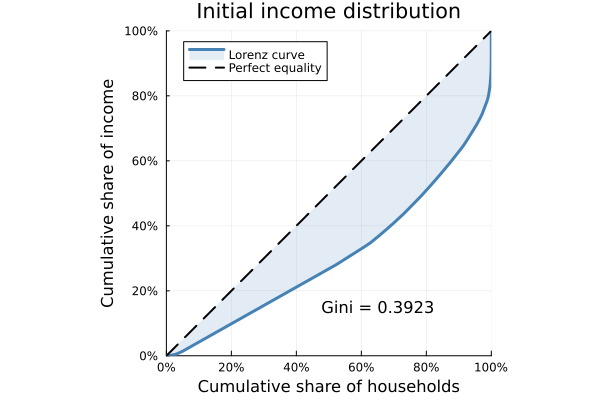

In [178]:
function lorenz_curve(values)
    sorted_values = sort(Float64.(values))

    isempty(sorted_values) &&
        throw(ArgumentError("The Lorenz curve requires at least one value"))

    any(value -> value < 0, sorted_values) &&
        throw(ArgumentError("The values must be non-negative"))

    total = sum(sorted_values)
    iszero(total) &&
        throw(ArgumentError("The Lorenz curve is undefined when all values are zero"))

    population_share = collect(range(
        0.0,
        1.0;
        length = length(sorted_values) + 1,
    ))

    cumulative_share = vcat(
        0.0,
        cumsum(sorted_values) ./ total,
    )

    area_below_lorenz = sum(
        diff(population_share) .*
        (
            cumulative_share[1:end-1] +
            cumulative_share[2:end]
        ) ./ 2
    )

    gini_value = 1 - 2 * area_below_lorenz

    return population_share, cumulative_share, gini_value
end

population_share, income_share, income_gini =
    lorenz_curve(initial_income)

percentage_ticks = (
    0:0.2:1,
    ["0%", "20%", "40%", "60%", "80%", "100%"],
)

plot(
    population_share,
    income_share;
    fillrange = population_share,
    fillalpha = 0.15,
    color = :steelblue,
    linewidth = 3,
    label = "Lorenz curve",
    xlabel = "Cumulative share of households",
    ylabel = "Cumulative share of income",
    title = "Initial income distribution",
    xticks = percentage_ticks,
    yticks = percentage_ticks,
    xlims = (0, 1),
    ylims = (0, 1),
    aspect_ratio = :equal,
)

plot!(
    population_share,
    population_share;
    color = :black,
    linestyle = :dash,
    linewidth = 2,
    label = "Perfect equality",
)

annotate!(
    0.65,
    0.15,
    text("Gini = $(round(income_gini; digits = 4))", 11),
)

## Agregados econômicos

Por fim, vamos analisar a situação inicial dos agregados econômicos da economia: 

- `simulation_period` (`model.agg.t`): período atual da simulação. Na inicialização, o valor é `1`.

- `current_gdp` (`last(model.agg.Y)`): PIB observado no último período histórico disponível.

- `current_inflation` (`last(model.agg.pi_)`): inflação observada no último período histórico disponível.

- `general_price_index` (`model.agg.P_bar`): índice geral de preços da economia.

- `consumer_price_index` (`model.agg.P_bar_HH`): índice de preços dos bens e serviços consumidos pelas famílias.

- `capital_price_index` (`model.agg.P_bar_CF`): índice de preços dos bens utilizados na formação de capital.

- `household_price_index` (`model.agg.P_bar_h`): índice de preços efetivamente observado nas compras realizadas pelas famílias.

- `household_capital_price_index` (`model.agg.P_bar_CF_h`): índice de preços efetivamente observado nos investimentos realizados pelas famílias.

Row,simulation_period,current_gdp,current_inflation,general_price_index,consumer_price_index,capital_price_index,household_price_index,household_capital_price_index,expected_gdp,expected_growth,expected_inflation,euro_area_gdp_shock,export_shock,import_shock,gambling_volume
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,1.34636e5,0.00100796,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


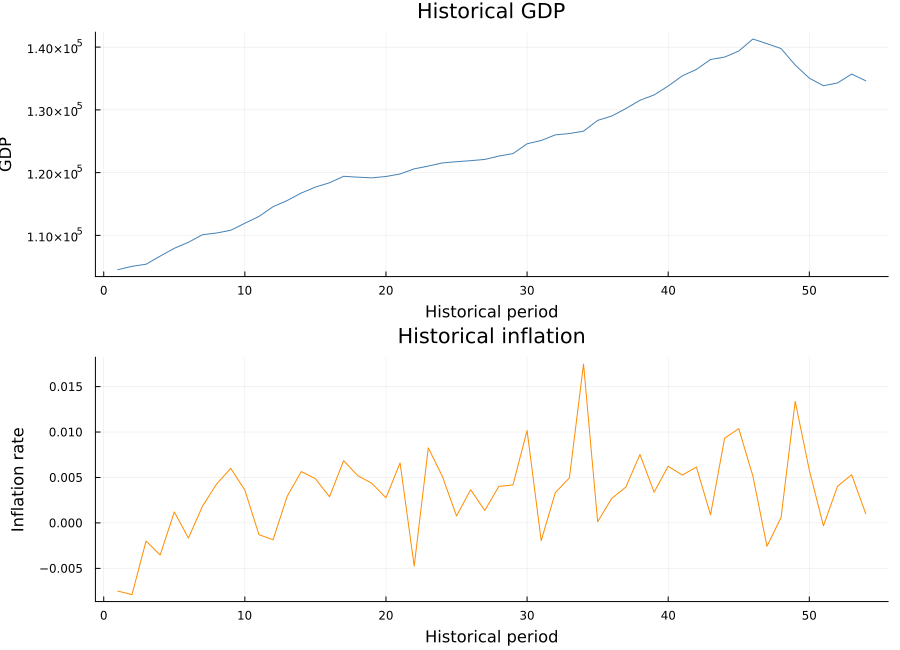

In [176]:
agg = model.agg

aggregate_state = DataFrame([
    (
        simulation_period = agg.t,
        current_gdp = last(agg.Y),
        current_inflation = last(agg.pi_),
        general_price_index = agg.P_bar,
        consumer_price_index = agg.P_bar_HH,
        capital_price_index = agg.P_bar_CF,
        household_price_index = agg.P_bar_h,
        household_capital_price_index = agg.P_bar_CF_h,
        expected_gdp = agg.Y_e,
        expected_growth = agg.gamma_e,
        expected_inflation = agg.pi_e,
        euro_area_gdp_shock = agg.epsilon_Y_EA,
        export_shock = agg.epsilon_E,
        import_shock = agg.epsilon_I,
        gambling_volume = agg.gambling_volume,
    ),
])

aggregate_history = DataFrame(
    period = eachindex(agg.Y),
    gdp = agg.Y,
    inflation = agg.pi_,
)

sector_price_indices = DataFrame(
    sector = eachindex(agg.P_bar_g),
    producer_price_index = agg.P_bar_g,
)

display(aggregate_state)

p1 = plot(
    aggregate_history.period,
    aggregate_history.gdp;
    title = "Historical GDP",
    xlabel = "Historical period",
    ylabel = "GDP",
    label = false,
    color = :steelblue,
)

p2 = plot(
    aggregate_history.period,
    aggregate_history.inflation;
    title = "Historical inflation",
    xlabel = "Historical period",
    ylabel = "Inflation rate",
    label = false,
    color = :darkorange,
)

plot(
    p1,
    p2;
    layout = (2, 1),
    size = (900, 650),
)

Nota: algumas variáveis de estado do modelo, como orçamentos e expectativas das famílias e empresas, têm valor zero no período inicial pois só são calculados durante a simulação. 

# Próximo passo: rodar a simulação passo a passo, entender as regras implementadas e como elas afetam as variáveis e resultados do modelo.